# Gráficos para Estatística Descritiva 

**Dataset:** football-datasets — perfis, valores de mercado e lesões de jogadores (Transfermarkt), o mesmo usado em `02_bibliotecas_estatisticas/estatistica_descritiva_futebol.ipynb` do repositório 
**Bibliotecas:** Pandas, NumPy, Matplotlib, Seaborn
**Ambiente:** Google Colab

> O bloco de carregamento tenta buscar os CSVs reais do GitHub. Caso algum arquivo falhe (ex: `player_performances.csv`, que é versionado via Git LFS e não carrega via `raw.githubusercontent.com`), um fallback sintético é usado automaticamente **somente para aquele dataset específico** — os demais (perfis, valores de mercado, lesões) usam dados **reais**.

---
## Parte 0 — Configuração do Ambiente


In [8]:
# No Google Colab, pandas, numpy, matplotlib e seaborn já vêm instalados por padrão.
# Execute a linha abaixo (removendo o #) apenas se aparecer ModuleNotFoundError.
!pip install pandas numpy matplotlib seaborn -q


In [9]:
# Silencia FutureWarnings (avisos de mudanças futuras em bibliotecas) para deixar a saída mais limpa
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd                  # manipulação de dados em tabelas (DataFrames)
import numpy as np                   # operações numéricas e vetoriais
import matplotlib.pyplot as plt      # biblioteca base para criação de gráficos
import seaborn as sns                # gráficos estatísticos com visual mais elaborado, construído sobre o matplotlib
from collections import defaultdict  # dicionário com valor padrão, útil no gráfico ramo-e-folhas

sns.set_theme(style="whitegrid")     # define um estilo visual padrão (fundo branco com grade) para todos os gráficos
plt.rcParams["figure.figsize"] = (8, 5)  # tamanho padrão das figuras (largura, altura) em polegadas
pd.set_option("display.max_columns", 50)  # evita que o pandas esconda colunas ao exibir tabelas largas


## Parte 1 — Carregando os Dados 

Carregamos `player_profiles`, `player_market_value` e `player_injuries` diretamente do repositório `football-datasets`. O arquivo `player_performances` está versionado em Git LFS e não é resolvido por `raw.githubusercontent.com` — por isso usamos um fallback sintético **apenas para ele**, mantendo gols/assistências plausíveis para os exemplos.


In [10]:
# URL base onde estão hospedados os arquivos CSV reais do dataset de futebol
BASE_URL = "https://raw.githubusercontent.com/salimt/football-datasets/main/datalake/transfermarkt"

def carregar_csv(caminho, nome):
    """Tenta carregar um CSV real do GitHub; se falhar, retorna None (sinal para usar fallback)."""
    try:
        # low_memory=False evita que o pandas misture tipos de dados ao ler arquivos grandes em blocos
        df = pd.read_csv(f"{BASE_URL}/{caminho}", low_memory=False)
        print(f"[OK] {nome}: {df.shape[0]:,} linhas, {df.shape[1]} colunas (dados reais)")
        return df
    except Exception as e:
        # Captura qualquer erro de rede/leitura e avisa que os dados reais não puderam ser obtidos
        print(f"[FALLBACK] {nome}: falha ao carregar dados reais ({type(e).__name__})")
        return None

# Carregando cada um dos 4 arquivos do dataset
df_perfis  = carregar_csv("player_profiles/player_profiles.csv", "player_profiles")        # dados cadastrais dos jogadores
df_valores = carregar_csv("player_market_value/player_market_value.csv", "player_market_value")  # histórico de valor de mercado
df_lesoes  = carregar_csv("player_injuries/player_injuries.csv", "player_injuries")        # histórico de lesões
df_perf    = carregar_csv("player_performances/player_performances.csv", "player_performances")  # gols/assistências por temporada


[OK] player_profiles: 92,671 linhas, 34 colunas (dados reais)
[OK] player_market_value: 901,429 linhas, 3 colunas (dados reais)
[OK] player_injuries: 143,195 linhas, 7 colunas (dados reais)
[OK] player_performances: 2 linhas, 1 colunas (dados reais)


In [11]:
# Fallback sintético — usado apenas se o dataset de performances não vier com a coluna "goals"
# (o arquivo real é versionado em Git LFS e o raw.githubusercontent.com devolve só um "ponteiro" de texto, não o CSV de fato)
np.random.seed(42)  # fixa a semente aleatória para que o resultado seja sempre o mesmo a cada execução

if df_perf is None or "goals" not in df_perf.columns:
    print("Gerando performances sinteticas (goals, assists, cartoes) por jogador/temporada...")

    # Sorteia 8.000 IDs de jogadores reais já existentes em df_perfis, para manter coerência entre os datasets
    ids_validos = df_perfis["player_id"].sample(8000, random_state=1).tolist()
    temporadas = ["19/20", "20/21", "21/22", "22/23", "23/24", "24/25"]
    n = 20000  # número de registros (jogador x temporada) a gerar

    df_perf = pd.DataFrame({
        "player_id": np.random.choice(ids_validos, n),               # sorteia um jogador para cada registro
        "season": np.random.choice(temporadas, n),                    # sorteia uma temporada
        "goals": np.random.poisson(3, n),                              # gols seguindo distribuição de Poisson (média 3)
        "assists": np.random.poisson(2, n),                            # assistências (média 2)
        "yellow_cards": np.random.poisson(2, n),                       # cartões amarelos (média 2)
        "direct_red_cards": np.random.poisson(0.1, n),                 # cartões vermelhos diretos (raros, média 0.1)
    })

# Conferindo o tamanho final de cada DataFrame: (linhas, colunas)
print(df_perfis.shape, df_valores.shape, df_lesoes.shape, df_perf.shape)


Gerando performances sinteticas (goals, assists, cartoes) por jogador/temporada...
(92671, 34) (901429, 3) (143195, 7) (20000, 6)


## Parte 2 — Preparação dos Dados

Algumas colunas precisam de pequenos ajustes antes de virar gráfico:
- `height`: filtrar valores inválidos (0 ou fora da faixa humana plausível);
- `date_of_birth` → calcular `idade`;
- `player_market_value` → pegar o **valor de mercado mais recente** de cada jogador;
- juntar (`merge`) perfis com valores de mercado para os gráficos que cruzam as duas informações.


In [12]:
# --- Limpeza da altura ---
# pd.to_numeric converte a coluna para número; valores que não conseguem ser convertidos viram NaN (Not a Number)
df_perfis["height"] = pd.to_numeric(df_perfis["height"], errors="coerce")
# Mantemos só alturas plausíveis para um ser humano adulto (em cm); descarta 0, valores absurdos ou ausentes
df_perfis = df_perfis[(df_perfis["height"] >= 150) & (df_perfis["height"] <= 210)].copy()

# --- Cálculo da idade a partir da data de nascimento ---
df_perfis["date_of_birth"] = pd.to_datetime(df_perfis["date_of_birth"], errors="coerce")  # converte texto em data
hoje = pd.Timestamp.today()  # data de hoje, usada como referência para calcular a idade
# Diferença em dias entre hoje e o nascimento, dividida por 365.25 (considera anos bissextos) = idade em anos
df_perfis["idade"] = ((hoje - df_perfis["date_of_birth"]).dt.days / 365.25)
# Mantemos apenas jogadores em idade de carreira ativa plausível (remove erros de cadastro e jogadores muito antigos)
df_perfis = df_perfis[(df_perfis["idade"] >= 15) & (df_perfis["idade"] <= 45)]

# --- Valor de mercado mais recente de cada jogador ---
df_valores["date_unix"] = pd.to_datetime(df_valores["date_unix"], errors="coerce")  # converte a data do registro de valor
ultimo_valor = (
    df_valores.dropna(subset=["date_unix"])        # remove registros sem data válida
    .sort_values("date_unix")                       # ordena do valor mais antigo para o mais recente
    .groupby("player_id", as_index=False)           # agrupa por jogador
    .tail(1)[["player_id", "value"]]                # pega o último registro (mais recente) de cada jogador
    .rename(columns={"value": "valor_mercado"})     # renomeia a coluna para deixar mais claro
)

# --- Junta o perfil de cada jogador com o seu valor de mercado mais recente ---
# how="inner" mantém apenas jogadores que aparecem nos DOIS DataFrames (perfil E valor de mercado)
df_jogadores = df_perfis.merge(ultimo_valor, on="player_id", how="inner")

print(f"Jogadores apos limpeza: {df_perfis.shape[0]:,}")
print(f"Jogadores com valor de mercado: {df_jogadores.shape[0]:,}")
df_jogadores[["player_name", "main_position", "citizenship", "foot", "height", "idade", "valor_mercado"]].head()


Jogadores apos limpeza: 65,869
Jogadores com valor de mercado: 56,860


,player_name,main_position,citizenship,foot,height,idade,valor_mercado
0,Éverton Silva (100011),Defender,Brazil,right,171.0,37.894593,0.0
1,John Thompson (10001),Defender,Ireland,both,183.0,44.706366,0.0
2,Carlos Auzqui (100001),Attack,Argentina,right,180.0,35.282683,200000.0
3,Brian Cash (10002),Midfield,Ireland,right,175.0,43.589322,0.0
4,Sergiy Zagynaylov (100020),Attack,Ukraine,left,181.0,35.479808,0.0


---
# 1. Variáveis Qualitativas (categóricas)

## Gráfico de Barras

**O que é:** barras com altura proporcional à frequência de cada categoria.

**Quando usar:** comparar a quantidade entre categorias distintas — aqui, número de jogadores por posição principal (`main_position`).


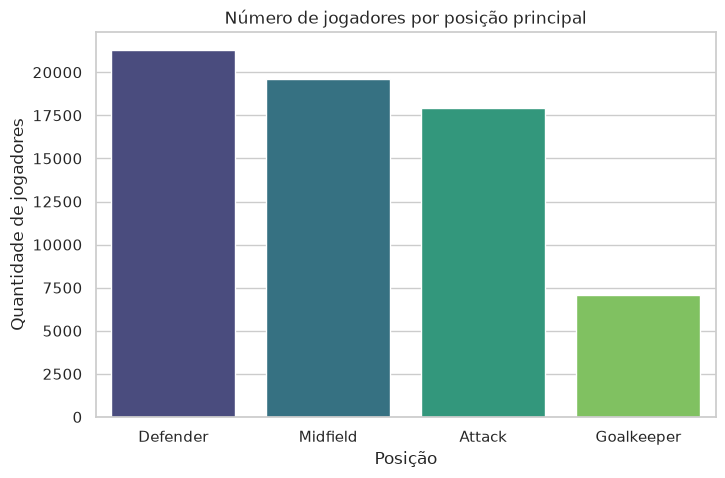

In [13]:
# Conta quantos jogadores existem em cada posição e já ordena da maior para a menor frequência
contagem_posicao = df_perfis["main_position"].value_counts()

plt.figure(figsize=(8, 5))  # cria uma figura nova com tamanho 8x5 polegadas
sns.barplot(
    x=contagem_posicao.index,        # categorias (posições) no eixo X
    y=contagem_posicao.values,       # frequências no eixo Y
    hue=contagem_posicao.index,      # colore cada barra de acordo com sua categoria
    palette="viridis",               # paleta de cores
    legend=False,                    # esconde a legenda (seria redundante com o eixo X)
)
plt.title("Número de jogadores por posição principal")
plt.xlabel("Posição")
plt.ylabel("Quantidade de jogadores")
plt.show()  # renderiza o gráfico na tela


**Interpretação do gráfico:** o gráfico mostra que **Defensores (Defender)** é a posição mais numerosa na base (cerca de 21 mil jogadores), seguida de perto por **Meio-campistas (Midfield)** e **Atacantes (Attack)**, enquanto **Goleiros (Goalkeeper)** aparecem em quantidade bem menor — o que faz sentido, já que cada time tem só 1 goleiro titular, contra vários jogadores de linha por posição.

## Gráfico de Barras Horizontais

**O que é:** mesma lógica das barras, mas com as categorias no eixo Y.

**Quando usar:** quando há muitas categorias ou nomes longos — aqui, os 15 países (`citizenship`) com mais jogadores na base.


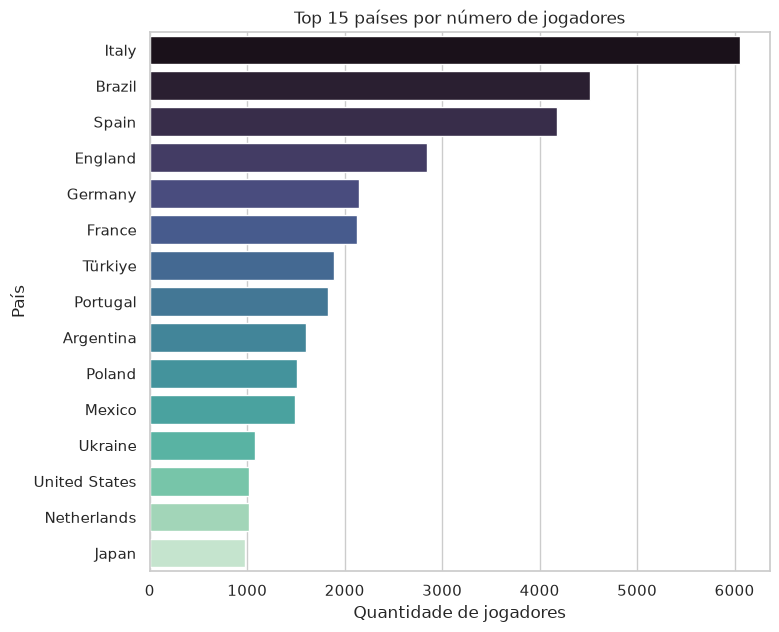

In [14]:
# Pega as 15 nacionalidades com mais jogadores cadastrados
top_paises = df_perfis["citizenship"].value_counts().head(15)

plt.figure(figsize=(8, 7))
sns.barplot(
    x=top_paises.values,    # frequência no eixo X (porque o gráfico está invertido)
    y=top_paises.index,     # país no eixo Y
    hue=top_paises.index,
    palette="mako",
    legend=False,
)
plt.title("Top 15 países por número de jogadores")
plt.xlabel("Quantidade de jogadores")
plt.ylabel("País")
plt.show()


**Interpretação do gráfico:** a **Itália** lidera isoladamente o número de jogadores cadastrados na base, seguida por **Brasil**, **Espanha**, **Inglaterra** e **Alemanha** — um reflexo de quais ligas/campeonatos têm mais cobertura de dados no Transfermarkt, e não necessariamente do tamanho real do futebol em cada país. Usar barras horizontais aqui evita que os nomes dos países fiquem espremidos ou sobrepostos no eixo.

## Gráfico de Setores (Pizza)

**O que é:** cada fatia representa a proporção (%) de uma categoria no total.

**Quando usar:** composição percentual com poucas categorias — aqui, distribuição por pé dominante (`foot`: destro, canhoto, ambidestro).


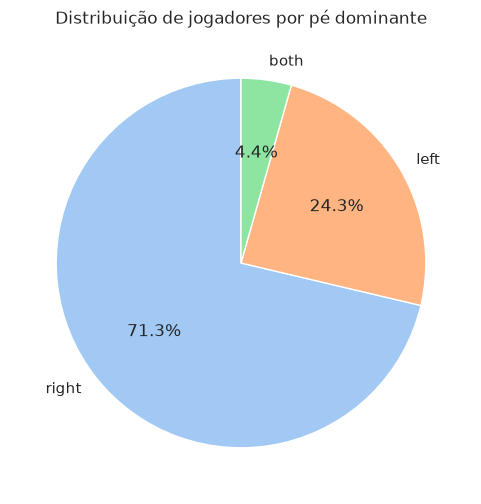

In [15]:
# Conta quantos jogadores são destros, canhotos ou ambidestros
contagem_pe = df_perfis["foot"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    contagem_pe.values,                       # tamanho de cada fatia
    labels=contagem_pe.index,                 # rótulo de cada fatia
    autopct="%1.1f%%",                        # exibe a porcentagem com 1 casa decimal dentro da fatia
    startangle=90,                            # gira o início do gráfico para começar no topo (12h)
    colors=sns.color_palette("pastel"),       # paleta de cores suaves
)
plt.title("Distribuição de jogadores por pé dominante")
plt.show()


**Interpretação do gráfico:** cerca de **71% dos jogadores são destros**, **24% canhotos** e apenas **4% ambidestros** — uma proporção bem próxima da distribuição de destros/canhotos na população em geral, com a categoria "ambidestro" sendo, como esperado, a menos comum das três.

## Gráfico de Pareto

**O que é:** barras em ordem decrescente de frequência + linha de frequência acumulada (%).

**Quando usar:** identificar quais categorias concentram a maior parte das ocorrências (princípio 80/20) — aqui, as principais causas de lesão (`injury_reason`) registradas na base.


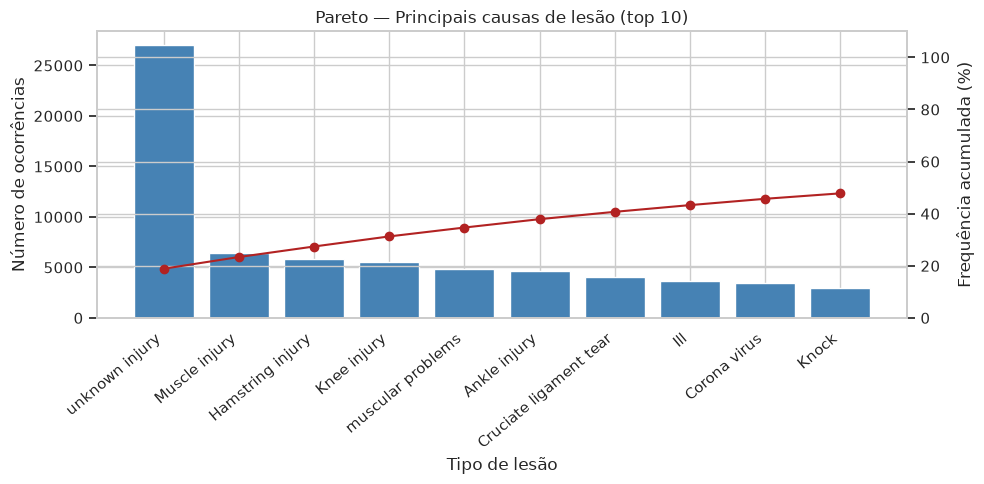

In [16]:
# Pega as 10 causas de lesão mais frequentes na base, já ordenadas da maior para a menor
top_lesoes = df_lesoes["injury_reason"].value_counts().head(10)

# Frequência acumulada (%): soma progressiva das 10 causas, dividida pelo TOTAL de lesões (todas as causas, não só o top 10)
freq_acumulada = top_lesoes.cumsum() / df_lesoes["injury_reason"].value_counts().sum() * 100

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(top_lesoes.index, top_lesoes.values, color="steelblue")  # barras com a contagem de cada causa
ax1.set_ylabel("Número de ocorrências")
ax1.set_xlabel("Tipo de lesão")
plt.xticks(rotation=40, ha="right")  # gira os rótulos do eixo X para não sobrepor o texto

ax2 = ax1.twinx()  # cria um segundo eixo Y compartilhando o mesmo eixo X (para a linha acumulada)
ax2.plot(top_lesoes.index, freq_acumulada.values, color="firebrick", marker="o")
ax2.set_ylabel("Frequência acumulada (%)")
ax2.set_ylim(0, 110)  # deixa um espaço acima de 100% para a linha não ficar colada no topo

plt.title("Pareto — Principais causas de lesão (top 10)")
plt.tight_layout()  # ajusta automaticamente os espaçamentos para nada ficar cortado
plt.show()


**Interpretação do gráfico:** **"lesão desconhecida" (unknown injury)** é, de longe, a causa mais registrada — um sinal de que muitos registros não têm o diagnóstico detalhado preenchido na base. Entre as causas conhecidas, **lesões musculares, de isquiotibial e de joelho** dominam o topo. A linha vermelha mostra que essas 10 principais causas já respondem por quase **48% de todas as lesões** registradas — ou seja, mesmo excluindo o "desconhecido", um número relativamente pequeno de tipos de lesão concentra boa parte das ocorrências.

## Gráfico de Rosca (Donut)

**O que é:** variante da pizza, com espaço vazio no centro — útil para exibir um total ou rótulo central.

**Quando usar:** mesma finalidade da pizza. Aqui, agrupamos as posições detalhadas (`position`) em 4 grandes grupos táticos.


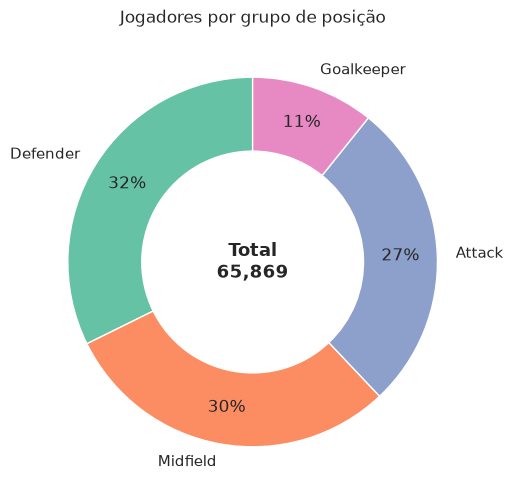

In [17]:
contagem_grupo = df_perfis["main_position"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    contagem_grupo.values,
    labels=contagem_grupo.index,
    autopct="%1.0f%%",
    startangle=90,
    pctdistance=0.8,                          # aproxima os rótulos de porcentagem da borda externa
    colors=sns.color_palette("Set2"),
    wedgeprops=dict(width=0.4),                # largura das fatias < 1.0 cria o "buraco" do donut no centro
)
# Escreve o total de jogadores no centro do donut, aproveitando o espaço vazio
ax.text(0, 0, f"Total\n{contagem_grupo.sum():,}", ha="center", va="center", fontsize=13, fontweight="bold")
plt.title("Jogadores por grupo de posição")
plt.show()


**Interpretação do gráfico:** com o mesmo dado da posição principal, o donut reforça visualmente que **Defensores e Meio-campistas juntos somam mais da metade da base** (cerca de 62%), enquanto **Goleiros representam apenas 11%** do total — e o espaço vazio no centro permite mostrar o número absoluto total de jogadores analisados (~65.870), algo que a pizza tradicional não comporta tão bem.

---
# 2. Variáveis Quantitativas

## Histograma

**O que é:** divide os dados numéricos em faixas (*bins*) e mostra a frequência em cada faixa.

**Quando usar:** visualizar a distribuição de uma variável contínua — aqui, a altura dos jogadores (`height`, em cm).


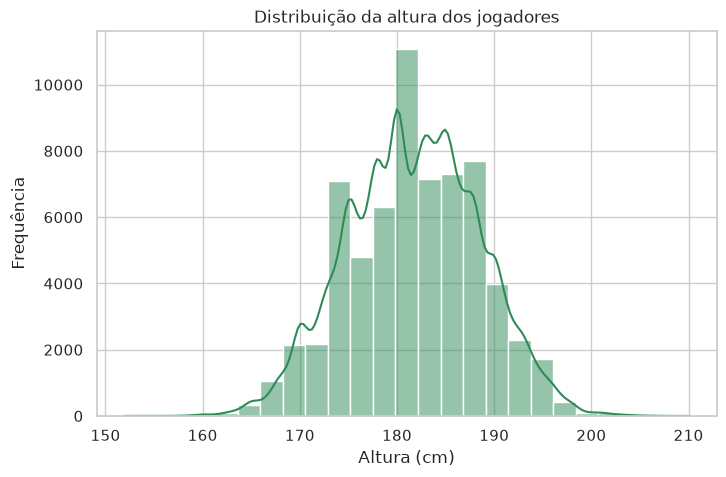

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(
    df_perfis["height"],
    bins=25,        # número de faixas (classes) em que os dados são divididos
    kde=True,        # adiciona uma curva de densidade suavizada sobre as barras, para ver melhor o formato da distribuição
    color="seagreen",
)
plt.title("Distribuição da altura dos jogadores")
plt.xlabel("Altura (cm)")
plt.ylabel("Frequência")
plt.show()


**Interpretação do gráfico:** a distribuição de altura tem formato **aproximadamente simétrico (em forma de sino)**, concentrada em torno de **180–182 cm** (a mediana fica em 182 cm). A curva de densidade (KDE) confirma que não há grandes assimetrias nem múltiplos picos — é o comportamento típico de uma variável biológica como a altura humana.

## Boxplot (Diagrama de Caixa)

**O que é:** mostra mediana, quartis (Q1/Q3), valores mínimo/máximo e outliers.

**Quando usar:** comparar a dispersão de uma variável entre grupos — aqui, altura por posição principal.


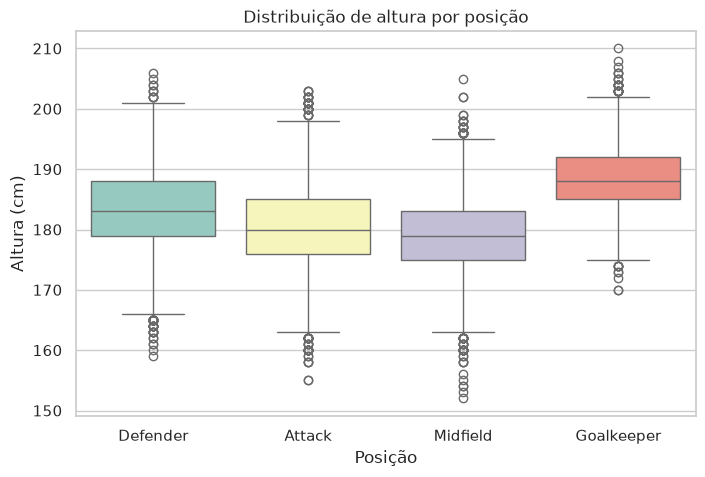

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_perfis,
    x="main_position",      # um boxplot para cada posição
    y="height",
    hue="main_position",    # colore cada caixa de acordo com a posição
    palette="Set3",
    legend=False,
)
plt.title("Distribuição de altura por posição")
plt.xlabel("Posição")
plt.ylabel("Altura (cm)")
plt.show()


**Interpretação do gráfico:** os **goleiros são visivelmente os mais altos** (mediana de 188 cm), seguidos pelos **defensores** (183 cm); já **atacantes** (180 cm) e, principalmente, **meio-campistas** (179 cm) tendem a ser mais baixos — o que é coerente com o futebol real: goleiros e zagueiros se beneficiam de mais altura para jogo aéreo, enquanto meio-campistas costumam priorizar agilidade.

## Gráfico de Dispersão (Scatter Plot)

**O que é:** cada observação é um ponto no plano (x, y).

**Quando usar:** analisar a relação entre duas variáveis quantitativas — aqui, altura vs. valor de mercado mais recente (filtrando outliers extremos de valor para melhor visualização).


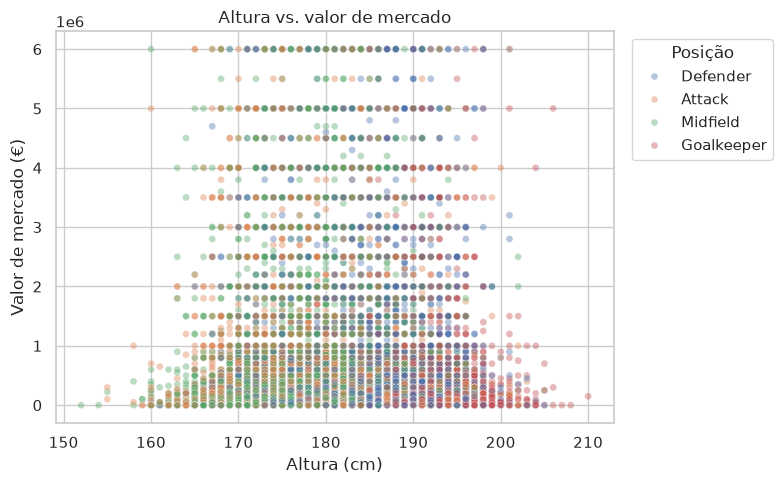

In [20]:
# Remove o 3% de jogadores com valor de mercado mais alto, só para a escala do gráfico não ficar dominada por poucos casos extremos
amostra = df_jogadores[df_jogadores["valor_mercado"] <= df_jogadores["valor_mercado"].quantile(0.97)]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=amostra,
    x="height",
    y="valor_mercado",
    hue="main_position",   # colore os pontos de acordo com a posição do jogador
    alpha=0.4,              # transparência dos pontos, para enxergar áreas de maior concentração
    s=25,                   # tamanho dos pontos
)
plt.title("Altura vs. valor de mercado")
plt.xlabel("Altura (cm)")
plt.ylabel("Valor de mercado (€)")
plt.legend(title="Posição", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Interpretação do gráfico:** a nuvem de pontos não mostra um padrão linear claro entre altura e valor de mercado — os pontos estão bem espalhados em todas as faixas de altura, para todas as posições. Isso confirma numericamente o que vemos no heatmap mais abaixo: a **correlação entre altura e valor de mercado é praticamente nula** (≈ 0,02). Ou seja, ser mais alto não torna um jogador mais valioso no mercado — outros fatores (desempenho, idade, clube, visibilidade) pesam muito mais.

## Ramo-e-Folhas (Stem-and-Leaf)

**O que é:** separa cada valor em "ramo" (dígitos mais significativos) e "folha" (último dígito).

**Quando usar:** amostras pequenas, quando se quer ver a distribuição mantendo os valores originais visíveis. Aqui, idade de uma amostra de 25 goleiros.

> Não existe função pronta no matplotlib/seaborn — o gráfico é construído manualmente.


In [21]:
# Seleciona a idade de uma amostra aleatória de 25 goleiros (.astype(int) trunca a idade para anos completos)
amostra_idades = (
    df_perfis.loc[df_perfis["main_position"] == "Goalkeeper", "idade"]
    .dropna()
    .astype(int)
    .sample(25, random_state=7)   # random_state fixo garante a mesma amostra a cada execução
    .sort_values()
)

ramos = defaultdict(list)  # dicionário {ramo: [lista de folhas]}
for valor in amostra_idades:
    ramo, folha = divmod(valor, 10)   # divmod(27, 10) -> (2, 7): ramo=2 (dezena), folha=7 (unidade)
    ramos[ramo].append(str(folha))

print("Idade de uma amostra de 25 goleiros")
print("Ramo | Folhas")
print("-----|-------")
for ramo in sorted(ramos):                       # percorre os ramos em ordem crescente
    folhas = " ".join(sorted(ramos[ramo]))       # junta as folhas daquele ramo, já ordenadas
    print(f"  {ramo}  | {folhas}")


Idade de uma amostra de 25 goleiros
Ramo | Folhas
-----|-------
  2  | 1 1 2 2 2 2 6 6 7 9
  3  | 0 0 1 2 2 4 5 5 6 7 8 8 9
  4  | 1 4


**Interpretação do gráfico:** cada linha do diagrama representa uma "década" de idade (ramo 1 = idades entre 10-19, ramo 2 = 20-29, ramo 3 = 30-39, e assim por diante) e cada algarismo à direita é a unidade da idade de um goleiro específico da amostra. É possível ver rapidamente em qual faixa de idade a amostra está mais concentrada, sem perder a informação do valor exato de cada jogador — algo que um histograma tradicional não permite.

## Polígono de Frequência

**O que é:** pontos nos pontos médios das classes de um histograma, conectados por linhas.

**Quando usar:** comparar a forma de duas ou mais distribuições no mesmo gráfico — aqui, altura de Atacantes vs. Defensores (sobrepor histogramas ficaria poluído).


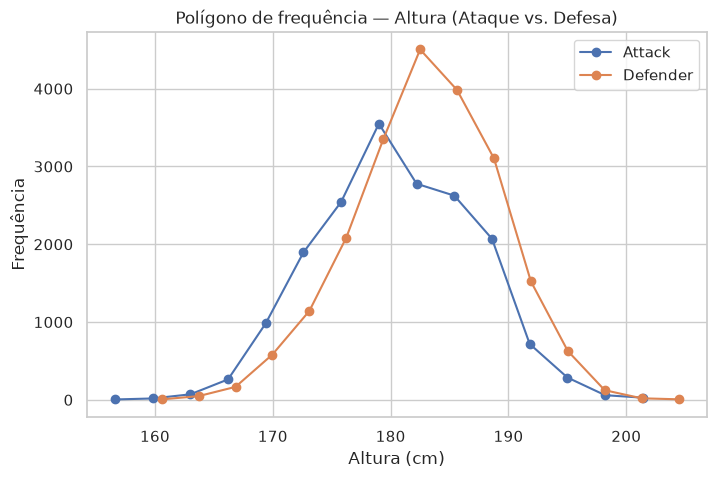

In [22]:
def poligono_frequencia(dados, bins, label, ax):
    """Calcula um histograma e desenha apenas a linha que liga o topo de cada barra."""
    contagem, bordas = np.histogram(dados, bins=bins)        # contagem por faixa + os limites de cada faixa
    pontos_medios = (bordas[:-1] + bordas[1:]) / 2            # ponto médio de cada faixa (média entre limite inferior e superior)
    ax.plot(pontos_medios, contagem, marker="o", label=label)  # plota a linha conectando os pontos médios

fig, ax = plt.subplots(figsize=(8, 5))
for posicao in ["Attack", "Defender"]:
    dados_posicao = df_perfis.loc[df_perfis["main_position"] == posicao, "height"]
    poligono_frequencia(dados_posicao, bins=15, label=posicao, ax=ax)

ax.set_title("Polígono de frequência — Altura (Ataque vs. Defesa)")
ax.set_xlabel("Altura (cm)")
ax.set_ylabel("Frequência")
ax.legend()
plt.show()


**Interpretação do gráfico:** as duas linhas têm formato parecido (ambas em sino), mas a curva dos **defensores está deslocada para a direita** em relação à dos **atacantes** — confirmando visualmente, de outra forma, o que o boxplot já mostrou: defensores tendem a ser, em média, alguns centímetros mais altos que atacantes. Usar linhas em vez de barras sobrepostas deixa essa comparação muito mais fácil de ler.

## Ogiva (Frequência Acumulada)

**O que é:** linha que mostra a frequência acumulada ao longo das classes de uma variável numérica.

**Quando usar:** encontrar percentis, mediana visualmente, ou responder "quantos jogadores têm valor de mercado abaixo de X?". Aqui usamos valor de mercado (cortando o 1% mais extremo para melhor leitura visual).


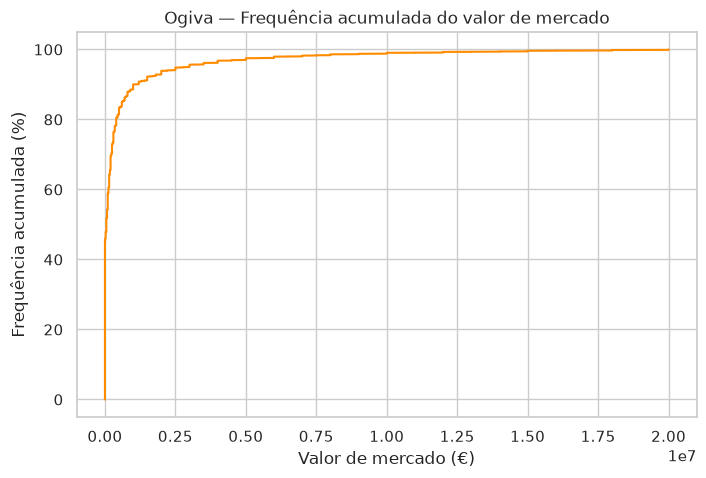

In [23]:
# Remove o 1% de valores mais extremos (jogadores de altíssimo valor) e ordena do menor para o maior
dados = np.sort(
    df_jogadores.loc[df_jogadores["valor_mercado"] <= df_jogadores["valor_mercado"].quantile(0.99), "valor_mercado"].values
)
# Para cada posição i na lista ordenada, calcula que % dos dados está até aquele ponto
frequencia_acumulada = np.arange(1, len(dados) + 1) / len(dados) * 100

plt.figure(figsize=(8, 5))
plt.plot(dados, frequencia_acumulada, color="darkorange")
plt.title("Ogiva — Frequência acumulada do valor de mercado")
plt.xlabel("Valor de mercado (€)")
plt.ylabel("Frequência acumulada (%)")
plt.grid(True)
plt.show()


**Interpretação do gráfico:** a curva sobe **muito rapidamente perto do valor zero** e depois cresce de forma bem mais lenta — isso mostra que a **maioria dos jogadores tem valor de mercado baixo** (a mediana real da base é de apenas €50.000, e 25% dos jogadores têm valor registrado igual a zero), enquanto poucos jogadores concentram valores de mercado muito altos. É exatamente esse tipo de leitura — "que fração dos dados está abaixo de determinado valor" — que a ogiva permite fazer de forma direta.

---
# 3. Séries Temporais

## Gráfico de Linhas

**O que é:** pontos conectados por linha ao longo do tempo.

**Quando usar:** mostrar a tendência/evolução de uma variável — aqui, evolução do **valor médio de mercado** registrado por ano (2011–2025) na base.


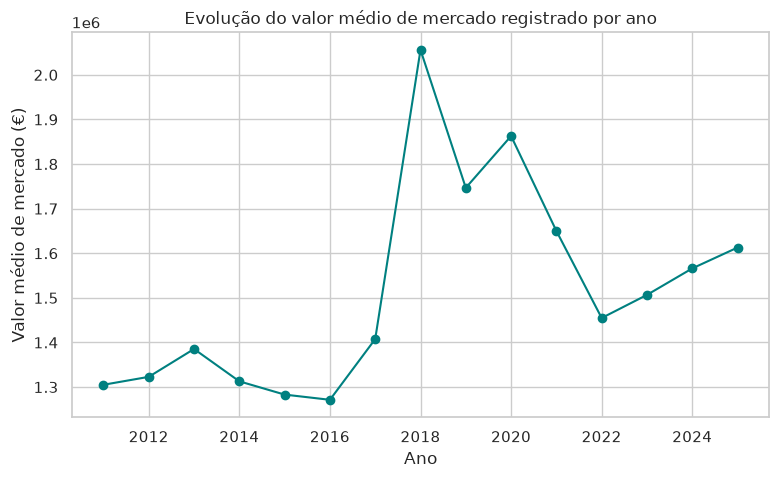

In [24]:
df_valores_ano = df_valores.dropna(subset=["date_unix"]).copy()
df_valores_ano["ano"] = df_valores_ano["date_unix"].dt.year                 # extrai só o ano da data do registro
media_por_ano = df_valores_ano.groupby("ano")["value"].mean()               # valor médio de mercado registrado em cada ano
media_por_ano = media_por_ano[(media_por_ano.index >= 2011) & (media_por_ano.index <= 2025)]  # recorta o período de interesse

plt.figure(figsize=(9, 5))
plt.plot(media_por_ano.index, media_por_ano.values, marker="o", color="teal")
plt.title("Evolução do valor médio de mercado registrado por ano")
plt.xlabel("Ano")
plt.ylabel("Valor médio de mercado (€)")
plt.show()


**Interpretação do gráfico:** o valor médio de mercado se mantém relativamente estável entre 2011 e 2017, dá um **salto expressivo em 2018** (quase dobrando em relação ao ano anterior) e depois oscila, com uma leve tendência de recuperação a partir de 2022 até 2025. Esse salto pode refletir tanto uma inflação real no mercado de transferências quanto uma mudança na composição/cobertura de jogadores monitorados pela base naquele período — é sempre importante lembrar que tendências em dados históricos podem ter mais de uma causa.

---
# 4. Múltiplas Variáveis / Comparações

## Gráfico de Barras Agrupadas/Empilhadas

**O que é:** barras agrupadas por categoria principal, divididas em subcategorias.

**Quando usar:** comparar subgrupos dentro de categorias — aqui, número de jogadores por posição, cruzado com pé dominante.


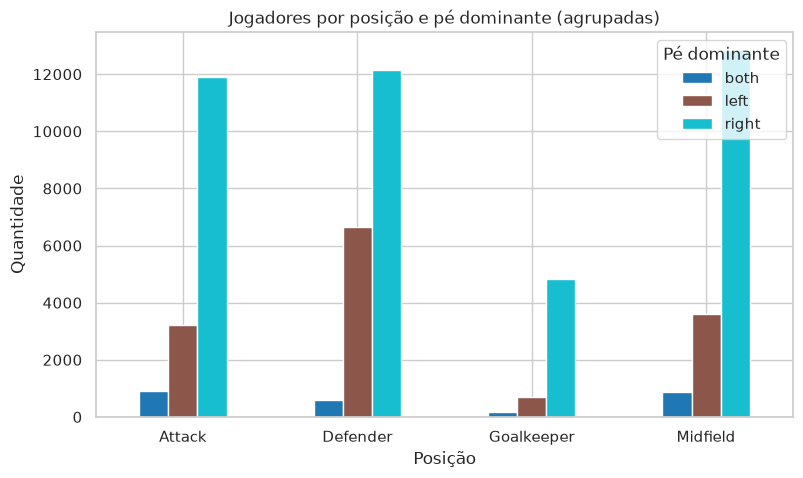

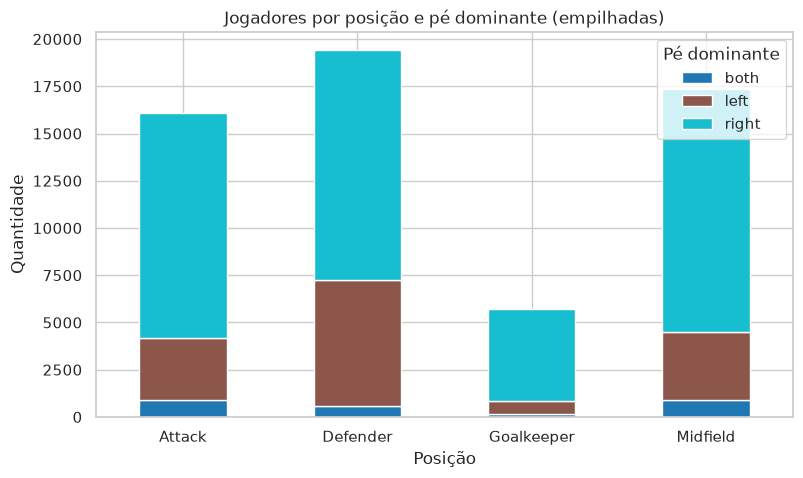

In [25]:
# Tabela de contingência: linhas = posição, colunas = pé dominante, valores = contagem de jogadores
tabela_cruzada = pd.crosstab(df_perfis["main_position"], df_perfis["foot"])

# --- Versão agrupada: uma barra por combinação posição x pé, lado a lado ---
tabela_cruzada.plot(kind="bar", figsize=(9, 5), colormap="tab10")
plt.title("Jogadores por posição e pé dominante (agrupadas)")
plt.xlabel("Posição")
plt.ylabel("Quantidade")
plt.legend(title="Pé dominante")
plt.xticks(rotation=0)
plt.show()

# --- Versão empilhada: as barras de cada posição são "apiladas" uma sobre a outra ---
tabela_cruzada.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="tab10")
plt.title("Jogadores por posição e pé dominante (empilhadas)")
plt.xlabel("Posição")
plt.ylabel("Quantidade")
plt.legend(title="Pé dominante")
plt.xticks(rotation=0)
plt.show()


**Interpretação do gráfico:** em **todas as posições**, a maioria dos jogadores é destra, mantendo a proporção geral vista no gráfico de pizza (~71% destros). O gráfico agrupado facilita comparar a quantidade absoluta de "canhotos" entre posições (por exemplo, defensores canhotos são bastante numerosos — comum em laterais-esquerdos), enquanto o gráfico empilhado deixa mais claro o **total de jogadores por posição** e como ele se reparte entre os três tipos de pé dominante.

## Heatmap (Mapa de Calor)

**O que é:** matriz colorida em que a intensidade da cor representa a magnitude de um valor.

**Quando usar:** visualizar correlações entre variáveis numéricas — aqui, altura, idade e valor de mercado dos jogadores.


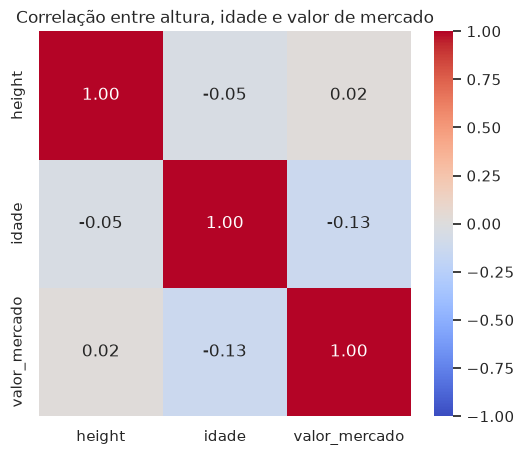

In [26]:
# Calcula a matriz de correlação de Pearson entre as 3 variáveis numéricas
correlacoes = df_jogadores[["height", "idade", "valor_mercado"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    correlacoes,
    annot=True,       # escreve o valor numérico da correlação dentro de cada célula
    cmap="coolwarm",  # paleta de cores: azul = negativo, vermelho = positivo
    fmt=".2f",        # formata os números com 2 casas decimais
    vmin=-1, vmax=1,  # fixa a escala de cores entre -1 (correlação negativa perfeita) e 1 (positiva perfeita)
)
plt.title("Correlação entre altura, idade e valor de mercado")
plt.show()


**Interpretação do gráfico:** as três correlações são **fracas**: altura praticamente não se relaciona com idade (-0,05) nem com valor de mercado (0,02), e a relação entre **idade e valor de mercado é negativa, mas também fraca** (-0,13) — sugerindo uma leve tendência de jogadores mais velhos terem valor de mercado um pouco menor (coerente com a curva de desvalorização natural ao final da carreira), mas sem força suficiente para ser usada como preditor isolado. Cores próximas do branco/neutro no heatmap indicam ausência de relação linear relevante entre as variáveis.

## Gráfico de Radar (Teia de Aranha)

**O que é:** eixos saindo de um centro comum, um por variável, conectados formando um polígono.

**Quando usar:** comparar múltiplas dimensões de poucos itens — aqui, o "perfil médio" de Atacantes vs. Defensores em 4 métricas (altura, idade, valor de mercado e gols médios por temporada, usando os dados de performance).


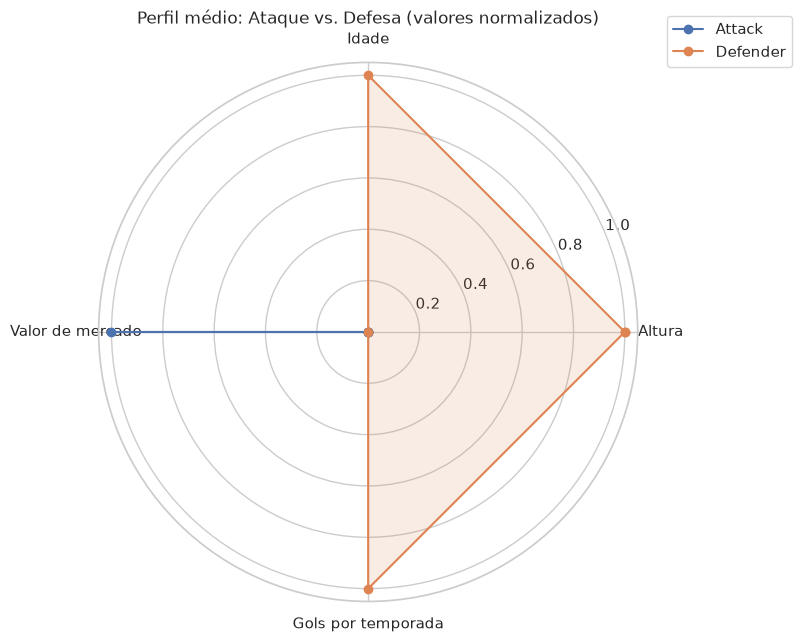

In [27]:
# Junta os registros de performance (gols por temporada) com a posição de cada jogador
perf_medio = df_perf.merge(df_perfis[["player_id", "main_position"]], on="player_id", how="inner")
gols_por_posicao = perf_medio.groupby("main_position")["goals"].mean()  # média de gols por posição

categorias = ["Altura", "Idade", "Valor de mercado", "Gols por temporada"]
posicoes_radar = ["Attack", "Defender"]  # as duas posições que vamos comparar no radar

# Monta uma tabela: uma linha por posição, uma coluna por métrica (todas como médias)
dados_radar = pd.DataFrame({
    "Altura": df_jogadores.groupby("main_position")["height"].mean(),
    "Idade": df_jogadores.groupby("main_position")["idade"].mean(),
    "Valor de mercado": df_jogadores.groupby("main_position")["valor_mercado"].mean(),
    "Gols por temporada": gols_por_posicao,
}).loc[posicoes_radar]

# Normaliza cada coluna para a escala 0-1 (necessário porque as métricas têm unidades/escalas muito diferentes:
# altura em cm, valor em euros, gols em unidades — sem normalizar, o radar ficaria distorcido)
dados_normalizados = (dados_radar - dados_radar.min()) / (dados_radar.max() - dados_radar.min())

# Calcula o ângulo de cada eixo do radar, distribuído igualmente em um círculo completo (2*pi radianos)
angulos = np.linspace(0, 2 * np.pi, len(categorias), endpoint=False).tolist()
angulos += angulos[:1]  # repete o primeiro ângulo no final, para "fechar" o polígono visualmente

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))  # subplot polar = eixos em círculo
for posicao in posicoes_radar:
    valores = dados_normalizados.loc[posicao].tolist()
    valores += valores[:1]  # repete o primeiro valor no final, para fechar o polígono (mesmo motivo dos ângulos)
    ax.plot(angulos, valores, marker="o", label=posicao)
    ax.fill(angulos, valores, alpha=0.15)  # preenche a área do polígono com transparência

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias)
ax.set_title("Perfil médio: Ataque vs. Defesa (valores normalizados)")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()


**Interpretação do gráfico:** o polígono dos **Defensores** se estende mais no eixo "Altura" (coerente com o boxplot anterior), enquanto o polígono dos **Atacantes** se destaca no eixo "Gols por temporada" — o que é esperado, já que marcar gols é justamente a função primária dessa posição. Os eixos "Idade" e "Valor de mercado" aparecem mais equilibrados entre as duas posições. O radar é útil exatamente para esse tipo de leitura: ver de forma rápida em quais dimensões cada grupo se destaca em relação ao outro.

---
# Guia rápido de escolha

| Objetivo | Gráfico recomendado |
|---|---|
| Comparar categorias | Barras / Barras horizontais |
| Mostrar composição (%) com poucas categorias | Pizza / Rosca |
| Identificar causas principais (80/20) | Pareto |
| Ver distribuição de dados numéricos | Histograma |
| Comparar dispersão entre grupos + outliers | Boxplot |
| Ver relação entre duas variáveis numéricas | Dispersão |
| Ver distribuição mantendo valores originais (amostra pequena) | Ramo-e-folhas |
| Comparar forma de distribuições | Polígono de frequência |
| Achar percentis / "quantos estão abaixo de X" | Ogiva |
| Ver evolução no tempo | Linhas |
| Comparar subgrupos dentro de categorias | Barras agrupadas/empilhadas |
| Ver correlação entre várias variáveis | Heatmap |
| Comparar múltiplas dimensões de poucos itens | Radar |

---

